# AI322 — Reinforcement Learning
# Programming Assignment 2: Comparing Dueling DDQN and PPO on Atari Pong

**Submitted by:** Anna Marie Benzon 
**Submitted to:** Dr. Prospero C. Naval, Jr.
**Course:** AI322 — Reinforcement Learning  

---

## Overview

This notebook implements and compares two deep reinforcement learning algorithms on the classic Atari **Pong** game:

| Algorithm | Category | Core Idea |
|-----------|----------|-----------|
| **Dueling Double DQN** | Off-policy, value-based | Separate V(s)/A(s,a) streams + double Q-learning + experience replay |
| **PPO** | On-policy, Actor-Critic | Clipped surrogate objective + GAE + multiple epochs per rollout |

### Pong Environment
- **Observation:** 4 stacked 84×84 grayscale frames (captures temporal motion)
- **Actions:** 6 discrete (NOOP, FIRE, RIGHT, LEFT, RIGHTFIRE, LEFTFIRE)
- **Reward:** +1 (you score), −1 (opponent scores), 0 otherwise
- **Episode terminates** when a player reaches 21 points

### Hyperparameter Study
For each algorithm, we vary:
- **Discount factor γ ∈ {0.95, 0.99}** — controls the horizon of reward maximization
- **Learning rate α ∈ {1×10⁻⁴, 2.5×10⁻⁴, 5×10⁻⁴}** — controls gradient update magnitude

We plot **sum of rewards per episode vs episode number** to compare convergence speed and final performance.

## 1. Installation

Install required packages. Run the cell below if needed.

In [ ]:
# ── Colab / local setup ────────────────────────────────────────────────────
import sys, os
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # Install required packages (only needed once per Colab session)
    import subprocess
    subprocess.run(['pip', 'install', '-q',
                    'gymnasium[atari,accept-rom-license]', 'ale-py',
                    'torch', 'matplotlib', 'numpy'], check=True)

    # Mount Google Drive so checkpoints survive a disconnect
    from google.colab import drive
    drive.mount('/content/drive')
    CHECKPOINT_DIR = '/content/drive/MyDrive/PA2_checkpoints'
else:
    CHECKPOINT_DIR = os.path.join(os.getcwd(), 'checkpoints')

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Checkpoint directory: {CHECKPOINT_DIR}')
print('All packages ready.')

Mounted at /content/drive
Checkpoint directory: /content/drive/MyDrive/PA2_checkpoints
All packages ready.


## 2. Imports & Global Configuration

In [ ]:
import ale_py
import gymnasium as gym
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque
import random
import time
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

# Register ALE environments with Gymnasium
gym.register_envs(ale_py)

# ─── Device ───────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # benchmark=True speeds up fixed-size convolutions on GPU;
    # note: this allows non-deterministic kernels, so GPU runs may not be
    # bit-for-bit reproducible even with the same seed.
    torch.backends.cudnn.benchmark = True

# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# ─── Training Mode ────────────────────────────────────────────────────────────
QUICK_MODE = False
COLAB_MODE = True   # ← set True when running on Google Colab

N_EPISODES       = 100  if QUICK_MODE else (300 if COLAB_MODE else 500)
LEARNING_STARTS  = 2000 if QUICK_MODE else (5000 if COLAB_MODE else 10000)
EPS_DECAY_STEPS  = 20000 if QUICK_MODE else (100000 if COLAB_MODE else 300000)
BUFFER_SIZE      = 20000 if QUICK_MODE else (50000 if COLAB_MODE else 100000)

mode_str = 'QUICK' if QUICK_MODE else ('COLAB' if COLAB_MODE else 'FULL')
print(f"\nTraining mode: {mode_str}")
print(f"Episodes/config: {N_EPISODES} | Buffer: {BUFFER_SIZE:,} | ε-decay: {EPS_DECAY_STEPS:,}")

Device: cuda
GPU: Tesla T4

Training mode: COLAB
Episodes/config: 300 | Buffer: 50,000 | ε-decay: 100,000


## 3. Environment Setup & Preprocessing

Standard Atari preprocessing pipeline (following Mnih et al., 2015):

1. **Frame skip (4):** Repeat action for 4 frames; take max over last 2 to handle sprite flickering
2. **Grayscale:** Convert 210×160 RGB → 84×84 grayscale
3. **No-op reset:** Apply 1–30 random no-ops at episode start for diverse initial states
4. **Frame stacking (4):** Stack 4 consecutive processed frames as the state representation

Final observation shape: **(4, 84, 84)** `uint8`

Observation shape : (4, 84, 84)
Observation dtype : uint8
Pixel value range : [52, 236]
Number of actions : 6
Action meanings   : NOOP, FIRE, RIGHT, LEFT, RIGHTFIRE, LEFTFIRE


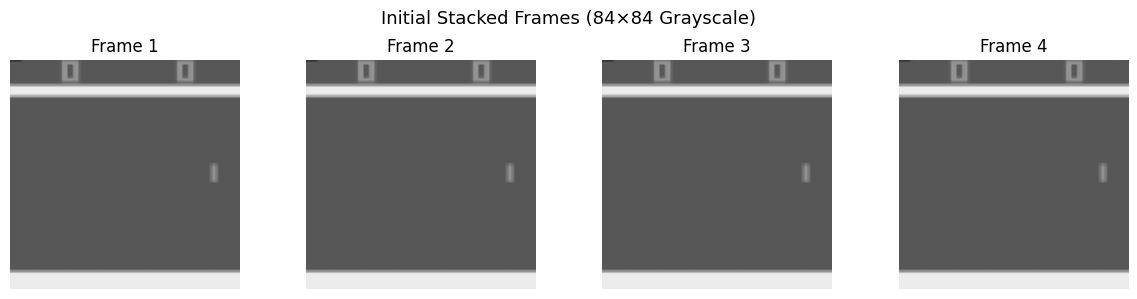

In [ ]:
def make_pong_env(seed: int = 42) -> gym.Env:
    """
    Create a preprocessed Pong environment.

    Returns an env with obs shape (4, 84, 84) uint8 and 6 discrete actions.
    """
    # frameskip=1 disables the default 2–4 random frameskip so AtariPreprocessing
    # can apply its own deterministic 4-frame skip
    env = gym.make("ALE/Pong-v5", render_mode=None, frameskip=1)
    env = AtariPreprocessing(
        env,
        screen_size=84,
        grayscale_obs=True,
        frame_skip=4,      # execute action for 4 frames; max-pool last 2
        noop_max=30,       # up to 30 random no-ops for diverse starts
        scale_obs=False    # keep uint8 [0,255]; normalize inside the network
    )
    env = FrameStackObservation(env, 4)  # stack 4 frames along first axis → (4,84,84)
    env.reset(seed=seed)
    return env


# ─── Sanity check ─────────────────────────────────────────────────────────────
env_test = make_pong_env()
obs, _ = env_test.reset()
obs_arr = np.array(obs)
print(f"Observation shape : {obs_arr.shape}")
print(f"Observation dtype : {obs_arr.dtype}")
print(f"Pixel value range : [{obs_arr.min()}, {obs_arr.max()}]")
print(f"Number of actions : {env_test.action_space.n}")
print(f"Action meanings   : NOOP, FIRE, RIGHT, LEFT, RIGHTFIRE, LEFTFIRE")
env_test.close()

# ─── Visualise initial stacked frames ─────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(obs_arr[i], cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Frame {i+1}')
    ax.axis('off')
fig.suptitle('Initial Stacked Frames (84×84 Grayscale)', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Dueling Double DQN (Dueling DDQN)

### Algorithm Overview

Dueling DDQN combines three improvements over vanilla DQN:

1. **Experience Replay** — transitions stored in a circular buffer; sampled uniformly to break correlation
2. **Target Network** — separate frozen network for TD target computation; synced every *K* steps
3. **Double Q-Learning** — online net selects the action, target net evaluates it:
   $$y_t = r_t + \gamma \cdot Q_{\theta^-}\!\left(s_{t+1},\, \arg\max_a Q_\theta(s_{t+1},a)\right)$$
4. **Dueling Architecture** — decomposes Q-values into value and advantage streams:
   $$Q(s,a) = V(s) + A(s,a) - \frac{1}{|\mathcal{A}|}\sum_{a'} A(s,a')$$

### CNN Architecture
```
Input (4×84×84)
  → Conv(32, 8×8, stride 4)  → ReLU  →  (32×20×20)
  → Conv(64, 4×4, stride 2)  → ReLU  →  (64×9×9)
  → Conv(64, 3×3, stride 1)  → ReLU  →  (64×7×7)  →  flatten 3136
         ┌──────────┴──────────┐
    Value stream          Advantage stream
    Linear(512)→ReLU      Linear(512)→ReLU
    Linear(1)             Linear(n_actions)
         └──────────┬──────────┘
              Q(s,a) = V + A − mean(A)
```

In [ ]:
class DuelingDQN(nn.Module):
    """
    Dueling DQN with the DeepMind CNN feature extractor.

    Separates state-value estimation V(s) from advantage estimation A(s,a).
    Combined: Q(s,a) = V(s) + A(s,a) − mean_a'[A(s,a')]
    """

    def __init__(self, n_actions: int):
        super().__init__()
        self.n_actions = n_actions

        # ── Shared CNN feature extractor ──────────────────────────────────────
        self.cnn = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),   # (B,4,84,84) → (B,32,20,20)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),  # → (B,64,9,9)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),  # → (B,64,7,7)
            nn.ReLU(),
        )
        # CNN output: 64 × 7 × 7 = 3136 features

        # ── Value stream: V(s) ────────────────────────────────────────────────
        self.value_stream = nn.Sequential(
            nn.Linear(3136, 512), nn.ReLU(),
            nn.Linear(512, 1)
        )

        # ── Advantage stream: A(s, a) ─────────────────────────────────────────
        self.advantage_stream = nn.Sequential(
            nn.Linear(3136, 512), nn.ReLU(),
            nn.Linear(512, n_actions)
        )

        self._init_weights()

    def _init_weights(self):
        """Orthogonal initialisation (better than default for RL)."""
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        # Output layers use smaller gain for stability
        nn.init.orthogonal_(self.value_stream[-1].weight, gain=1.0)
        nn.init.orthogonal_(self.advantage_stream[-1].weight, gain=1.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x: uint8 or float tensor of shape (B, 4, 84, 84)
        Returns:
            Q-values of shape (B, n_actions)
        """
        x = x.float() / 255.0                       # normalise to [0,1]
        features = self.cnn(x).flatten(start_dim=1)  # (B, 3136)

        v = self.value_stream(features)              # (B, 1)
        a = self.advantage_stream(features)          # (B, n_actions)

        # Identifiable decomposition: subtract mean advantage
        return v + a - a.mean(dim=1, keepdim=True)


# ─── Quick architecture test ──────────────────────────────────────────────────
net_test = DuelingDQN(n_actions=6)
dummy_input = torch.zeros(2, 4, 84, 84)  # batch of 2
out = net_test(dummy_input)
print(f"DuelingDQN output shape: {out.shape}  (expected: [2, 6])")

total_params = sum(p.numel() for p in net_test.parameters())
print(f"Total parameters: {total_params:,}")

DuelingDQN output shape: torch.Size([2, 6])  (expected: [2, 6])
Total parameters: 3,293,863


In [ ]:
class ReplayBuffer:
    """
    Pre-allocated circular replay buffer for Atari observations.

    Stores states as uint8 (saves ~8× memory vs float32) and
    converts to float tensors only at sample time.
    """

    def __init__(self, capacity: int, obs_shape: tuple = (4, 84, 84)):
        self.capacity = capacity
        self.ptr = 0    # write pointer
        self.size = 0   # current fill level

        # Pre-allocate arrays for maximum efficiency
        self.states      = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.next_states = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.actions     = np.zeros(capacity, dtype=np.int64)
        self.rewards     = np.zeros(capacity, dtype=np.float32)
        self.dones       = np.zeros(capacity, dtype=np.float32)

    def push(self, state, action: int, reward: float, next_state, done: bool):
        """Store one transition."""
        np.copyto(self.states[self.ptr],      np.asarray(state,      dtype=np.uint8))
        np.copyto(self.next_states[self.ptr], np.asarray(next_state, dtype=np.uint8))
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.dones[self.ptr]   = float(done)

        self.ptr  = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size: int):
        """Sample a random mini-batch; returns GPU tensors."""
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.tensor(self.states[idx],      dtype=torch.float32, device=device),
            torch.tensor(self.actions[idx],                          device=device),
            torch.tensor(self.rewards[idx],                          device=device),
            torch.tensor(self.next_states[idx], dtype=torch.float32, device=device),
            torch.tensor(self.dones[idx],                            device=device),
        )

    def __len__(self) -> int:
        return self.size


print("ReplayBuffer defined.")

ReplayBuffer defined.


In [ ]:
class DDQNAgent:
    """
    Dueling Double DQN agent.

    Key design choices:
    - Online net selects actions; target net evaluates them (double Q-trick)
    - Huber loss (smooth L1) for gradient stability
    - Linear ε-greedy annealing from ε_start to ε_end over eps_decay_steps
    - Hard target network sync every target_update_freq environment steps
    """

    def __init__(
        self, n_actions: int,
        lr:                 float = 2.5e-4,
        gamma:              float = 0.99,
        buffer_size:        int   = 100_000,
        batch_size:         int   = 32,
        target_update_freq: int   = 1000,
        eps_start:          float = 1.0,
        eps_end:            float = 0.01,
        eps_decay_steps:    int   = 300_000,
    ):
        self.n_actions          = n_actions
        self.gamma              = gamma
        self.batch_size         = batch_size
        self.target_update_freq = target_update_freq
        self.eps_start          = eps_start
        self.eps_end            = eps_end
        self.eps_decay_steps    = eps_decay_steps
        self.steps              = 0  # incremented every env step by train_ddqn()

        # Online network (trained) and target network (frozen copy)
        self.online = DuelingDQN(n_actions).to(device)
        self.target = DuelingDQN(n_actions).to(device)
        self.target.load_state_dict(self.online.state_dict())
        self.target.eval()

        # Adam with small epsilon for numerical stability (recommended for Atari)
        self.optimizer = optim.Adam(self.online.parameters(), lr=lr, eps=1.5e-4)
        self.buffer    = ReplayBuffer(buffer_size)

    @property
    def epsilon(self) -> float:
        """Current exploration rate, linearly annealed over environment steps."""
        frac = min(1.0, self.steps / self.eps_decay_steps)
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    @torch.no_grad()
    def act(self, state) -> int:
        """ε-greedy action selection."""
        if random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        x = torch.tensor(np.asarray(state), dtype=torch.float32, device=device).unsqueeze(0)
        return self.online(x).argmax(dim=1).item()

    def learn(self) -> float | None:
        """
        Sample a mini-batch and perform one gradient update.
        Returns the loss value, or None if buffer is not full enough.
        self.steps is managed by the training loop so that epsilon and
        target-network sync are correctly tied to environment-step count.
        """
        if len(self.buffer) < self.batch_size:
            return None

        s, a, r, s2, done = self.buffer.sample(self.batch_size)

        # ── Double DQN target ─────────────────────────────────────────────────
        with torch.no_grad():
            # Online net picks best action in next state
            next_a = self.online(s2).argmax(dim=1, keepdim=True)
            # Target net evaluates that action (reduces overestimation bias)
            next_q = self.target(s2).gather(1, next_a).squeeze(1)
            target_q = r + self.gamma * next_q * (1.0 - done)

        # ── Current Q-values ──────────────────────────────────────────────────
        current_q = self.online(s).gather(1, a.unsqueeze(1)).squeeze(1)

        # Huber loss is less sensitive to outliers than MSE
        loss = F.smooth_l1_loss(current_q, target_q)

        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping prevents exploding gradients
        nn.utils.clip_grad_norm_(self.online.parameters(), max_norm=10.0)
        self.optimizer.step()

        # ── Periodic hard target network sync (env-step frequency) ────────────
        if self.steps % self.target_update_freq == 0:
            self.target.load_state_dict(self.online.state_dict())

        return loss.item()


print("DDQNAgent defined.")

DDQNAgent defined.


In [ ]:
def train_ddqn(
    n_episodes:         int   = 500,
    lr:                 float = 2.5e-4,
    gamma:              float = 0.99,
    buffer_size:        int   = 100_000,
    batch_size:         int   = 32,
    learning_starts:    int   = 10_000,
    train_freq:         int   = 4,
    target_update_freq: int   = 1_000,
    eps_start:          float = 1.0,
    eps_end:            float = 0.01,
    eps_decay_steps:    int   = 300_000,
    seed:               int   = 42,
    verbose:            bool  = True,
    print_every:        int   = 25,
) -> list:
    """
    Train a Dueling DDQN agent on Pong.

    Returns:
        List of total undiscounted rewards per episode.
    """
    env   = make_pong_env(seed=seed)
    agent = DDQNAgent(
        n_actions=env.action_space.n,
        lr=lr, gamma=gamma,
        buffer_size=buffer_size, batch_size=batch_size,
        target_update_freq=target_update_freq,
        eps_start=eps_start, eps_end=eps_end, eps_decay_steps=eps_decay_steps,
    )

    episode_rewards = []
    global_step     = 0
    t_start         = time.time()

    for ep in range(1, n_episodes + 1):
        state, _  = env.reset()
        ep_reward = 0.0
        done      = False

        while not done:
            action = agent.act(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Reward clipping: {-1, 0, +1} stabilises training across games
            agent.buffer.push(state, action, np.clip(reward, -1, 1), next_state, done)
            state      = next_state
            ep_reward += reward
            global_step    += 1
            agent.steps    += 1  # tie epsilon and target-sync to env-step count

            # Begin learning after warm-up; update every train_freq steps
            if global_step >= learning_starts and global_step % train_freq == 0:
                agent.learn()

        episode_rewards.append(ep_reward)

        if verbose and ep % print_every == 0:
            window  = episode_rewards[-print_every:]
            elapsed = (time.time() - t_start) / 60
            print(f"  Ep {ep:4d}/{n_episodes} "
                  f"| Avg({print_every}): {np.mean(window):6.1f} "
                  f"| Max: {max(window):4.0f} "
                  f"| ε: {agent.epsilon:.3f} "
                  f"| Steps: {global_step:,} "
                  f"| {elapsed:.1f} min")

    env.close()
    return episode_rewards


print("train_ddqn() defined.")

train_ddqn() defined.


---
## 5. Proximal Policy Optimization (PPO)

### Algorithm Overview

PPO is an on-policy Actor-Critic algorithm that prevents destructively large policy updates using a **clipped surrogate objective**:

$$L^{CLIP}(\theta) = \mathbb{E}_t \left[ \min\!\left( r_t(\theta)\hat{A}_t,\; \text{clip}(r_t(\theta), 1{-}\epsilon, 1{+}\epsilon)\hat{A}_t \right) \right]$$

where $r_t(\theta) = \pi_\theta(a_t|s_t) / \pi_{\theta_{\text{old}}}(a_t|s_t)$.

**Generalized Advantage Estimation (GAE)** reduces variance while controlling bias:
$$\hat{A}_t = \sum_{l=0}^{T-t-1} (\gamma\lambda)^l \delta_{t+l}, \quad \delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$$

**Full loss function:**
$$L = -L^{CLIP} + c_1 \cdot L^{VF} - c_2 \cdot H[\pi_\theta]$$

### Network Architecture
```
Input (4×84×84)
  → Shared CNN (same as DDQN)
  → FC(512, ReLU)
       ┌──────────┴──────────┐
  Actor head              Critic head
  Linear(n_actions)       Linear(1)
  → Categorical dist      → V(s)
```

In [ ]:
class PPONet(nn.Module):
    """
    Shared CNN backbone with separate actor (policy) and critic (value) heads.

    The shared feature extractor allows the actor and critic to jointly learn
    a useful state representation, improving sample efficiency.
    """

    def __init__(self, n_actions: int):
        super().__init__()

        # ── Shared feature extractor (same DeepMind CNN as DDQN) ──────────────
        self.cnn = nn.Sequential(
            nn.Conv2d(4, 32, kernel_size=8, stride=4),   # → (B,32,20,20)
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),  # → (B,64,9,9)
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),  # → (B,64,7,7)
            nn.ReLU(),
        )
        self.fc = nn.Sequential(nn.Linear(3136, 512), nn.ReLU())

        # ── Actor head: outputs action logits ────────────────────────────────
        self.actor  = nn.Linear(512, n_actions)
        # ── Critic head: outputs scalar state value ───────────────────────────
        self.critic = nn.Linear(512, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.zeros_(m.bias)
        # Actor output: tiny gain → near-uniform initial policy
        nn.init.orthogonal_(self.actor.weight,  gain=0.01)
        # Critic output: unit gain
        nn.init.orthogonal_(self.critic.weight, gain=1.0)

    def _features(self, x: torch.Tensor) -> torch.Tensor:
        x = x.float() / 255.0
        return self.fc(self.cnn(x).flatten(start_dim=1))  # (B, 512)

    def get_value(self, x: torch.Tensor) -> torch.Tensor:
        """Compute V(s) for a batch of states."""
        return self.critic(self._features(x))  # (B, 1)

    def get_action_and_value(
        self, x: torch.Tensor, action: torch.Tensor | None = None
    ):
        """
        Given states, sample (or evaluate) actions and return:
            action, log_prob, entropy, value
        """
        features = self._features(x)
        dist     = Categorical(logits=self.actor(features))
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(features)


net_ppo_test = PPONet(n_actions=6)
dummy         = torch.zeros(4, 4, 84, 84)
a, lp, ent, v = net_ppo_test.get_action_and_value(dummy)
print(f"PPONet: action {a.shape}, log_prob {lp.shape}, entropy {ent.shape}, value {v.shape}")
print(f"PPONet parameters: {sum(p.numel() for p in net_ppo_test.parameters()):,}")

PPONet: action torch.Size([4]), log_prob torch.Size([4]), entropy torch.Size([4]), value torch.Size([4, 1])
PPONet parameters: 1,687,719


In [ ]:
class PPOAgent:
    """
    Proximal Policy Optimization agent for discrete action spaces.

    Implements:
    - Fixed-length rollout collection (n_steps)
    - Generalised Advantage Estimation (GAE)
    - Clipped surrogate policy loss
    - Clipped value function loss
    - Entropy bonus for exploration
    - Multiple epochs + random mini-batches per rollout
    """

    def __init__(
        self, n_actions:     int,
        lr:                  float = 2.5e-4,
        gamma:               float = 0.99,
        gae_lambda:          float = 0.95,
        clip_eps:            float = 0.1,
        value_coef:          float = 0.5,
        entropy_coef:        float = 0.01,
        n_steps:             int   = 128,
        n_epochs:            int   = 4,
        n_minibatches:       int   = 4,
        max_grad_norm:       float = 0.5,
    ):
        self.gamma         = gamma
        self.gae_lambda    = gae_lambda
        self.clip_eps      = clip_eps
        self.value_coef    = value_coef
        self.entropy_coef  = entropy_coef
        self.n_steps       = n_steps
        self.n_epochs      = n_epochs
        self.minibatch_sz  = n_steps // n_minibatches
        self.max_grad_norm = max_grad_norm

        self.net       = PPONet(n_actions).to(device)
        self.optimizer = optim.Adam(self.net.parameters(), lr=lr, eps=1e-5)

    # ── Rollout collection ────────────────────────────────────────────────────
    def collect(self, env, state, ep_reward_cur: float = 0.0):
        """
        Collect n_steps transitions from the environment.

        Returns:
            Rollout buffers (obs, acts, logps, vals, returns, advantages)
            + the state at end of rollout (for bootstrap)
            + list of completed episode rewards
        """
        obs   = np.zeros((self.n_steps, 4, 84, 84), dtype=np.uint8)
        acts  = np.zeros(self.n_steps,               dtype=np.int64)
        logps = np.zeros(self.n_steps,               dtype=np.float32)
        vals  = np.zeros(self.n_steps,               dtype=np.float32)
        rews  = np.zeros(self.n_steps,               dtype=np.float32)
        dones = np.zeros(self.n_steps,               dtype=np.float32)

        ep_rewards    = []

        for t in range(self.n_steps):
            obs[t] = np.asarray(state, dtype=np.uint8)

            x = torch.tensor(obs[t:t+1], dtype=torch.float32, device=device)
            with torch.no_grad():
                a, logp, _, v = self.net.get_action_and_value(x)

            acts[t]  = a.item()
            logps[t] = logp.item()
            vals[t]  = v.item()

            state, rew, term, trunc, _ = env.step(acts[t])
            done = term or trunc

            rews[t]  = np.clip(rew, -1, 1)  # reward clipping for stability
            dones[t] = float(done)
            ep_reward_cur += rew             # track unclipped for reporting

            if done:
                ep_rewards.append(ep_reward_cur)
                ep_reward_cur = 0.0
                state, _ = env.reset()

        # ── Bootstrap: estimate value of the state after the rollout ──────────
        with torch.no_grad():
            x_last    = torch.tensor(np.asarray(state, dtype=np.uint8)[None],
                                     dtype=torch.float32, device=device)
            next_val  = self.net.get_value(x_last).item()

        # ── GAE computation (backward pass through rollout) ───────────────────
        adv = np.zeros_like(rews)
        gae = 0.0
        for t in reversed(range(self.n_steps)):
            next_v    = next_val if t == self.n_steps - 1 else vals[t + 1]
            mask      = 1.0 - dones[t]           # 0 at terminal states
            delta     = rews[t] + self.gamma * next_v * mask - vals[t]
            gae       = delta + self.gamma * self.gae_lambda * mask * gae
            adv[t]    = gae

        returns = adv + vals  # used as regression target for value function
        return obs, acts, logps, vals, returns, adv, state, ep_rewards, ep_reward_cur

    # ── PPO gradient update ───────────────────────────────────────────────────
    def update(self, obs, acts, old_logps, old_vals, returns, adv):
        """
        Perform n_epochs of mini-batch gradient updates on the collected rollout.
        """
        # Normalise advantages for stable updates
        adv = (adv - adv.mean()) / (adv.std() + 1e-8)

        # Convert to tensors once
        T_obs     = torch.tensor(obs,       dtype=torch.float32, device=device)
        T_acts    = torch.tensor(acts,                           device=device)
        T_logps   = torch.tensor(old_logps,                      device=device)
        T_returns = torch.tensor(returns,                         device=device)
        T_adv     = torch.tensor(adv,                             device=device)
        T_oldvals = torch.tensor(old_vals,                        device=device)

        n = len(obs)
        for _ in range(self.n_epochs):
            perm = np.random.permutation(n)
            for start in range(0, n, self.minibatch_sz):
                mb = perm[start : start + self.minibatch_sz]

                _, new_logps, entropy, new_vals = self.net.get_action_and_value(
                    T_obs[mb], T_acts[mb]
                )
                new_vals = new_vals.squeeze(-1)

                # ── Clipped surrogate (policy) loss ───────────────────────────
                ratio    = torch.exp(new_logps - T_logps[mb])
                pg_loss1 = -T_adv[mb] * ratio
                pg_loss2 = -T_adv[mb] * ratio.clamp(1 - self.clip_eps, 1 + self.clip_eps)
                policy_loss = torch.max(pg_loss1, pg_loss2).mean()

                # ── Clipped value function loss ────────────────────────────────
                v_clip  = T_oldvals[mb] + (new_vals - T_oldvals[mb]).clamp(
                              -self.clip_eps, self.clip_eps)
                # element-wise max before mean (standard PPO clipped value loss)
                vf_loss = torch.max(
                    F.mse_loss(new_vals, T_returns[mb], reduction='none'),
                    F.mse_loss(v_clip,   T_returns[mb], reduction='none')
                ).mean()

                # ── Total loss ────────────────────────────────────────────────
                loss = (policy_loss
                        + self.value_coef  * vf_loss
                        - self.entropy_coef * entropy.mean())

                self.optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.net.parameters(), self.max_grad_norm)
                self.optimizer.step()


print("PPOAgent defined.")

PPOAgent defined.


In [ ]:
def train_ppo(
    n_episodes:   int   = 500,
    lr:           float = 2.5e-4,
    gamma:        float = 0.99,
    gae_lambda:   float = 0.95,
    clip_eps:     float = 0.1,
    value_coef:   float = 0.5,
    entropy_coef: float = 0.01,
    n_steps:      int   = 128,
    n_epochs:     int   = 4,
    n_minibatches:int   = 4,
    seed:         int   = 42,
    verbose:      bool  = True,
    print_every:  int   = 25,
) -> list:
    """
    Train a PPO agent on Pong.

    PPO collects fixed-length rollouts (n_steps) rather than full episodes.
    Episodes complete naturally when `done=True` occurs within a rollout.

    Returns:
        List of total undiscounted rewards per completed episode (up to n_episodes).
    """
    env   = make_pong_env(seed=seed)
    agent = PPOAgent(
        n_actions=env.action_space.n,
        lr=lr, gamma=gamma,
        gae_lambda=gae_lambda, clip_eps=clip_eps,
        value_coef=value_coef, entropy_coef=entropy_coef,
        n_steps=n_steps, n_epochs=n_epochs, n_minibatches=n_minibatches,
    )

    episode_rewards = []
    ep_reward_cur   = 0.0
    state, _        = env.reset()
    t_start         = time.time()

    while len(episode_rewards) < n_episodes:
        obs, acts, logps, vals, returns, adv, state, ep_rews, ep_reward_cur = \
            agent.collect(env, state, ep_reward_cur)

        agent.update(obs, acts, logps, vals, returns, adv)
        episode_rewards.extend(ep_rews)

        if verbose and len(episode_rewards) >= print_every:
            n    = len(episode_rewards)
            prev = getattr(train_ppo, '_last_printed', 0)
            if n - prev >= print_every:
                window  = episode_rewards[max(0, n - print_every):]
                elapsed = (time.time() - t_start) / 60
                print(f"  Ep {n:4d}/{n_episodes} "
                      f"| Avg({print_every}): {np.mean(window):6.1f} "
                      f"| Max: {max(window):4.0f} "
                      f"| {elapsed:.1f} min")
                train_ppo._last_printed = n

    env.close()
    if hasattr(train_ppo, '_last_printed'):
        del train_ppo._last_printed
    return episode_rewards[:n_episodes]


print("train_ppo() defined.")

train_ppo() defined.


---
## 6. Plotting Utilities

In [ ]:
def moving_average(rewards: list, window: int = 50) -> np.ndarray:
    """Compute centered trailing moving average."""
    kernel = np.ones(window) / window
    # Pad to avoid edge shrinkage
    padded = np.pad(rewards, (window - 1, 0), mode='edge')
    return np.convolve(padded, kernel, mode='valid')


def plot_hyperparameter_study(
    results: dict,
    title:   str,
    smooth_window: int = 30,
    figsize: tuple = (16, 5),
) -> plt.Figure:
    """
    Two-panel figure:
      Left  — episode rewards (raw + smoothed) for each configuration
      Right — final performance (mean of last 50 episodes) bar chart
    """
    n_configs = len(results)
    palette   = plt.cm.tab10(np.linspace(0, 0.9, n_configs))

    fig, (ax_curve, ax_bar) = plt.subplots(1, 2, figsize=figsize)

    labels, final_perfs = [], []

    for (label, rewards), color in zip(results.items(), palette):
        eps  = np.arange(1, len(rewards) + 1)
        smoothed = moving_average(rewards, smooth_window)

        ax_curve.plot(eps, rewards,   alpha=0.15, color=color, linewidth=0.8)
        ax_curve.plot(eps, smoothed,  alpha=1.0,  color=color, linewidth=2.0,
                      label=label)

        labels.append(label)
        final_perfs.append(np.mean(rewards[-50:]))

    ax_curve.set_xlabel('Episode', fontsize=12)
    ax_curve.set_ylabel('Total Reward per Episode', fontsize=12)
    ax_curve.set_title(f'{title}\nRewards vs Episodes', fontsize=13)
    ax_curve.legend(fontsize=9, loc='lower right')
    ax_curve.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax_curve.grid(True, alpha=0.25)

    x_pos = np.arange(n_configs)
    bars  = ax_bar.bar(x_pos, final_perfs, color=palette, edgecolor='black',
                       linewidth=0.6)
    for bar, val in zip(bars, final_perfs):
        ax_bar.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.3,
                    f"{val:.1f}", ha='center', va='bottom', fontsize=8)

    ax_bar.set_xticks(x_pos)
    ax_bar.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
    ax_bar.set_ylabel('Mean Reward (last 50 episodes)', fontsize=12)
    ax_bar.set_title(f'{title}\nFinal Performance Summary', fontsize=13)
    ax_bar.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6)
    ax_bar.grid(True, alpha=0.25, axis='y')

    plt.tight_layout()
    plt.show()
    return fig


def plot_gamma_lr_grid(results: dict, title: str, gammas: list, lrs: list) -> plt.Figure:
    """
    3×2 grid of learning curves separated by γ and lr.
    Rows = learning rates, Columns = gamma values.
    """
    fig, axes = plt.subplots(len(lrs), len(gammas), figsize=(14, 3.5 * len(lrs)),
                              sharex=True, sharey=True)
    fig.suptitle(title, fontsize=14, y=1.01)

    for i, lr in enumerate(lrs):
        for j, gamma in enumerate(gammas):
            ax    = axes[i][j] if len(lrs) > 1 else axes[j]
            key = f'γ={gamma}, lr={lr:.0e}'
            if key not in results:
                key = f'γ={gamma}, lr={lr}'
            if key not in results:
                ax.set_title(f'γ={gamma}, lr={lr:.0e} — no data', fontsize=11, color="gray")
                continue
            rews  = results[key]
            eps   = np.arange(1, len(rews) + 1)
            ax.plot(eps, rews, alpha=0.15, color='steelblue')
            ax.plot(eps, moving_average(rews, 30), color='steelblue', lw=2)
            ax.axhline(0, color='gray', ls='--', lw=0.8)
            ax.set_title(f'γ={gamma}, lr={lr:.0e}', fontsize=11)
            ax.grid(True, alpha=0.25)
            if i == len(lrs) - 1:
                ax.set_xlabel('Episode', fontsize=10)
            if j == 0:
                ax.set_ylabel('Reward', fontsize=10)

    plt.tight_layout()
    plt.show()
    return fig


print("Plotting utilities defined.")

Plotting utilities defined.


---
## 7. Hyperparameter Experiments — Dueling DDQN

We train Dueling DDQN with all combinations of:

| Hyperparameter | Values tested |
|----------------|---------------|
| Discount γ     | 0.95, 0.99    |
| Learning rate α | 1×10⁻⁴, 2.5×10⁻⁴, 5×10⁻⁴ |

Fixed for all runs: buffer = `BUFFER_SIZE`, batch = 32, ε: 1.0 → 0.01 over `EPS_DECAY_STEPS` steps, target sync every 1000 steps.

In [ ]:
GAMMAS = [0.95, 0.99]
LRS    = [1e-4, 2.5e-4, 5e-4]

# ─── Run or load DDQN experiments ────────────────────────────────────────────
DDQN_CACHE = os.path.join(CHECKPOINT_DIR, f'ddqn_results_n{N_EPISODES}.pkl')

if os.path.exists(DDQN_CACHE):
    print(f"Loading cached DDQN results from '{DDQN_CACHE}'")
    with open(DDQN_CACHE, 'rb') as f:
        ddqn_results = pickle.load(f)
else:
    ddqn_results = {}

    for gamma in GAMMAS:
        for lr in LRS:
            label = f'γ={gamma}, lr={lr:.0e}'
            if label in ddqn_results:
                print(f"Skipping (already done): {label}")
                continue

            print(f"\n{'='*60}")
            print(f"DDQN  |  {label}")
            print(f"{'='*60}")

            rewards = train_ddqn(
                n_episodes=N_EPISODES,
                lr=lr,
                gamma=gamma,
                buffer_size=BUFFER_SIZE,
                batch_size=32,
                learning_starts=LEARNING_STARTS,
                train_freq=4,
                target_update_freq=1000,
                eps_start=1.0,
                eps_end=0.01,
                eps_decay_steps=EPS_DECAY_STEPS,
                seed=SEED,
                verbose=True,
                print_every=25,
            )
            ddqn_results[label] = rewards

            final_avg = np.mean(rewards[-50:])
            print(f"  → Final avg reward (last 50 ep): {final_avg:.2f}")

            # Save incrementally
            with open(DDQN_CACHE, 'wb') as f:
                pickle.dump(ddqn_results, f)

    print("\nAll DDQN runs complete. Results saved.")

# ─── Summary ─────────────────────────────────────────────────────────────────
print("\nDDQN Results Summary (mean reward over last 50 episodes):")
print("-" * 55)
for label, rewards in sorted(ddqn_results.items()):
    print(f"  {label:30s}  →  {np.mean(rewards[-50:]):6.2f}")

Loading cached DDQN results from '/content/drive/MyDrive/PA2_checkpoints/ddqn_results_n300.pkl'

DDQN Results Summary (mean reward over last 50 episodes):
-------------------------------------------------------
  γ=0.95, lr=1e-04                →  -17.98
  γ=0.95, lr=2.5e-4                →  -14.06
  γ=0.95, lr=5e-04                →  -10.28
  γ=0.99, lr=1e-04                →  -14.74
  γ=0.99, lr=2.5e-4                →   -4.82
  γ=0.99, lr=5e-04                →   -1.00


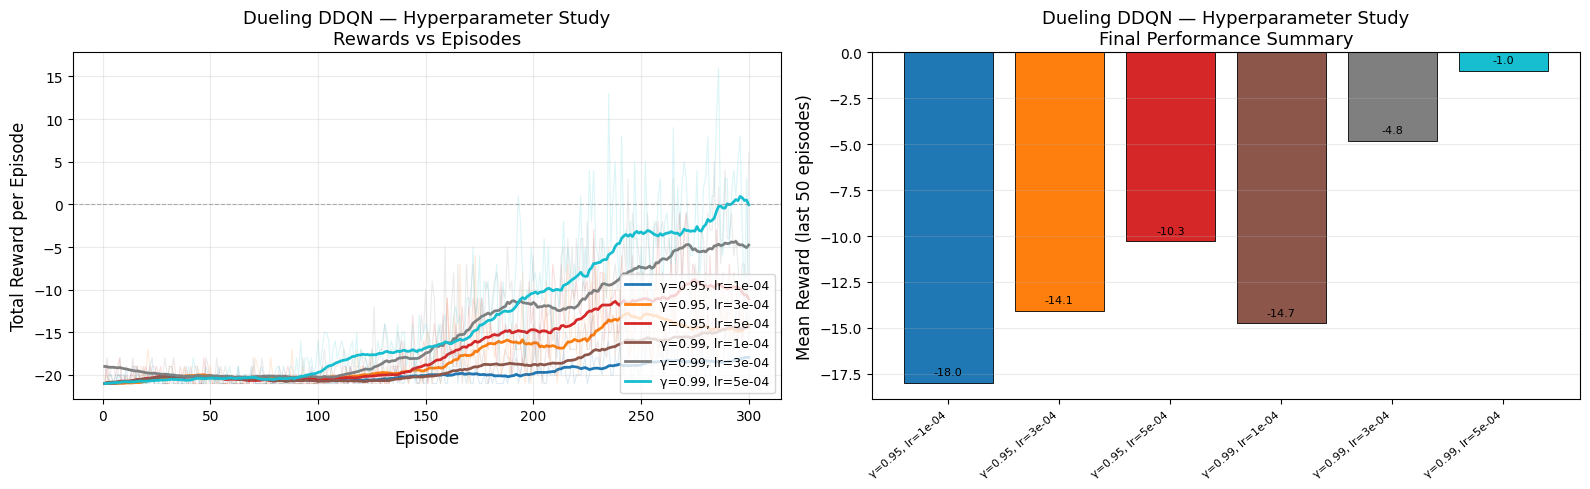

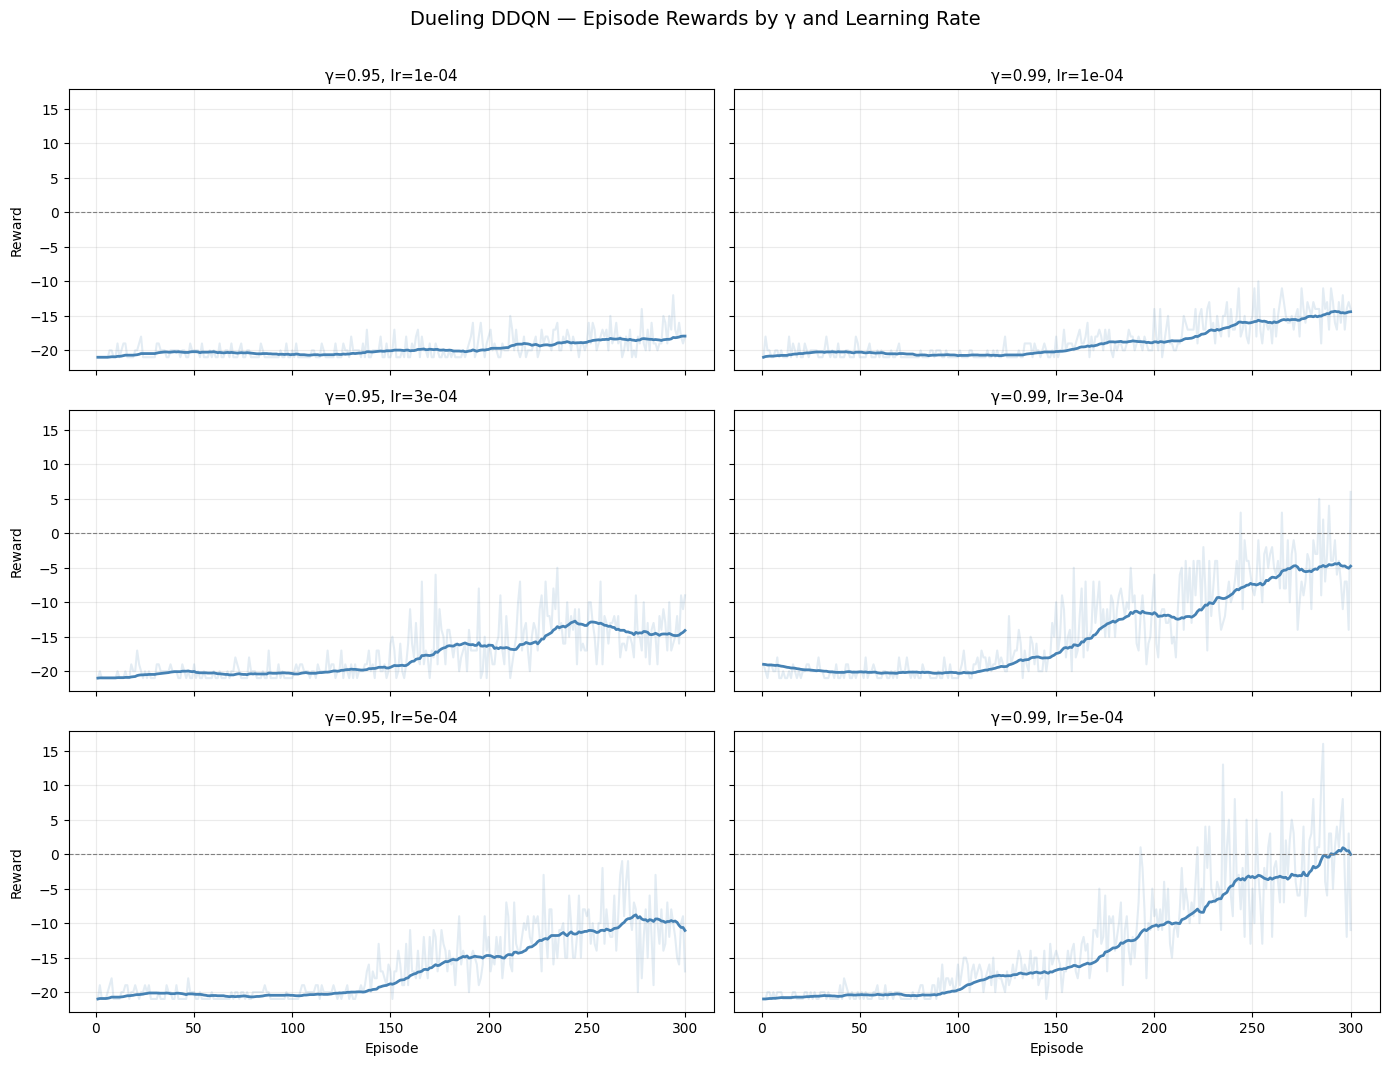

Best LR: 5e-04  |  Best γ: 0.99


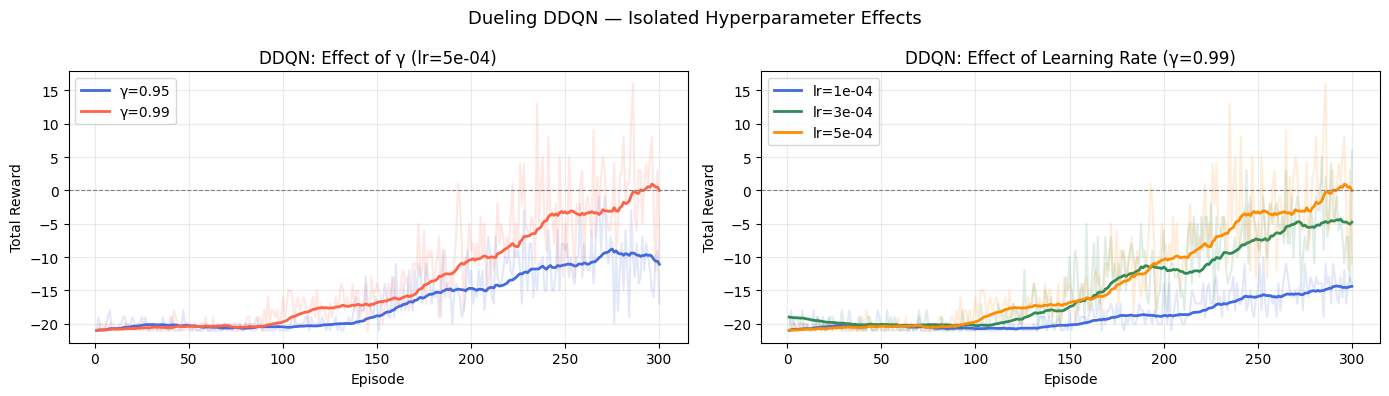

In [ ]:
# ─── All-in-one comparison ────────────────────────────────────────────────────
plot_hyperparameter_study(
    ddqn_results,
    title='Dueling DDQN — Hyperparameter Study',
    smooth_window=30,
)

# ─── Grid view: rows = LR, cols = gamma ───────────────────────────────────────
plot_gamma_lr_grid(
    ddqn_results,
    title='Dueling DDQN — Episode Rewards by γ and Learning Rate',
    gammas=GAMMAS,
    lrs=LRS,
)

# ─── Effect of gamma (fixed best LR) ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Derive best hyperparameters from actual run results
tail = min(50, N_EPISODES // 5)
best_lr = max(LRS, key=lambda lr: np.mean([
    np.mean(ddqn_results[f'\u03b3={g}, lr={lr:.0e}'][-tail:]) for g in GAMMAS]))
best_gamma = max(GAMMAS, key=lambda g: np.mean([
    np.mean(ddqn_results[f'\u03b3={g}, lr={lr:.0e}'][-tail:]) for lr in LRS]))
lr_colors  = ['royalblue', 'seagreen', 'darkorange']
print(f'Best LR: {best_lr:.0e}  |  Best γ: {best_gamma}')

# Gamma comparison at best lr
for gamma, color in zip(GAMMAS, ['royalblue', 'tomato']):
    key  = f'γ={gamma}, lr={best_lr:.0e}'
    rews = ddqn_results[key]
    eps  = np.arange(1, len(rews) + 1)
    axes[0].plot(eps, rews, alpha=0.15, color=color)
    axes[0].plot(eps, moving_average(rews, 30), color=color, lw=2, label=f'γ={gamma}')
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_title(f'DDQN: Effect of γ (lr={best_lr:.0e})', fontsize=12)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Total Reward')
axes[0].legend(); axes[0].grid(True, alpha=0.25)

# LR comparison at best gamma
for lr, color in zip(LRS, lr_colors):
    key  = f'γ={best_gamma}, lr={lr:.0e}'
    rews = ddqn_results[key]
    eps  = np.arange(1, len(rews) + 1)
    axes[1].plot(eps, rews, alpha=0.15, color=color)
    axes[1].plot(eps, moving_average(rews, 30), color=color, lw=2, label=f'lr={lr:.0e}')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_title(f'DDQN: Effect of Learning Rate (γ={best_gamma})', fontsize=12)
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Total Reward')
axes[1].legend(); axes[1].grid(True, alpha=0.25)

plt.suptitle('Dueling DDQN — Isolated Hyperparameter Effects', fontsize=13)
plt.tight_layout()
plt.show()

---
## 8. Hyperparameter Experiments — PPO

Same γ and lr grid as DDQN. Fixed PPO hyperparameters: GAE λ=0.95, clip ε=0.1, value coef=0.5, entropy coef=0.01, rollout n_steps=128, n_epochs=4, n_minibatches=4.

In [ ]:
# ─── Run or load PPO experiments ─────────────────────────────────────────────
PPO_CACHE = os.path.join(CHECKPOINT_DIR, f'ppo_results_n{N_EPISODES}.pkl')

if os.path.exists(PPO_CACHE):
    print(f"Loading cached PPO results from '{PPO_CACHE}'")
    with open(PPO_CACHE, 'rb') as f:
        ppo_results = pickle.load(f)
else:
    ppo_results = {}

    for gamma in GAMMAS:
        for lr in LRS:
            label = f'γ={gamma}, lr={lr:.0e}'
            if label in ppo_results:
                print(f"Skipping (already done): {label}")
                continue

            print(f"\n{'='*60}")
            print(f"PPO   |  {label}")
            print(f"{'='*60}")

            rewards = train_ppo(
                n_episodes=N_EPISODES,
                lr=lr,
                gamma=gamma,
                gae_lambda=0.95,
                clip_eps=0.1,
                value_coef=0.5,
                entropy_coef=0.01,
                n_steps=128,
                n_epochs=4,
                n_minibatches=4,
                seed=SEED,
                verbose=True,
                print_every=25,
            )
            ppo_results[label] = rewards

            final_avg = np.mean(rewards[-50:])
            print(f"  → Final avg reward (last 50 ep): {final_avg:.2f}")

            with open(PPO_CACHE, 'wb') as f:
                pickle.dump(ppo_results, f)

    print("\nAll PPO runs complete. Results saved.")

# ─── Summary ─────────────────────────────────────────────────────────────────
print("\nPPO Results Summary (mean reward over last 50 episodes):")
print("-" * 55)
for label, rewards in sorted(ppo_results.items()):
    print(f"  {label:30s}  →  {np.mean(rewards[-50:]):6.2f}")


PPO   |  γ=0.95, lr=1e-04
  Ep   25/300 | Avg(25):   -2.3 | Max:   -1 | 1.2 min
  Ep   50/300 | Avg(25):   -2.2 | Max:   -1 | 2.4 min
  Ep   75/300 | Avg(25):   -2.2 | Max:   -1 | 3.7 min
  Ep  100/300 | Avg(25):   -2.4 | Max:   -1 | 5.1 min
  Ep  125/300 | Avg(25):   -2.0 | Max:   -1 | 6.5 min
  Ep  150/300 | Avg(25):   -1.9 | Max:   -1 | 7.9 min
  Ep  175/300 | Avg(25):   -2.6 | Max:   -1 | 9.3 min
  Ep  200/300 | Avg(25):   -2.2 | Max:    0 | 10.8 min
  Ep  225/300 | Avg(25):   -2.1 | Max:   -1 | 12.3 min
  Ep  250/300 | Avg(25):   -2.1 | Max:    0 | 13.8 min
  Ep  275/300 | Avg(25):   -2.4 | Max:   -1 | 15.4 min
  Ep  300/300 | Avg(25):   -1.9 | Max:    0 | 16.9 min
  → Final avg reward (last 50 ep): -2.16

PPO   |  γ=0.95, lr=2.5e-4
  Ep   25/300 | Avg(25):   -2.2 | Max:   -1 | 1.5 min
  Ep   50/300 | Avg(25):   -2.0 | Max:   -1 | 2.9 min
  Ep   75/300 | Avg(25):   -2.0 | Max:    0 | 4.4 min
  Ep  100/300 | Avg(25):   -2.0 | Max:    0 | 6.0 min
  Ep  125/300 | Avg(25):   -1.7 | M

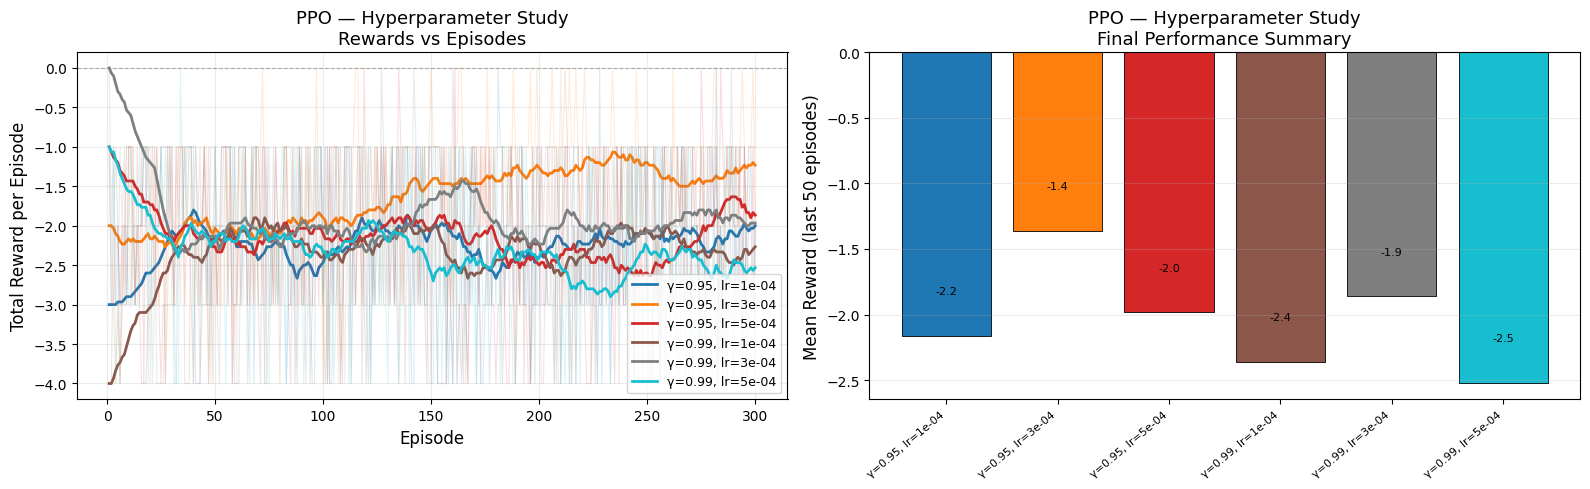

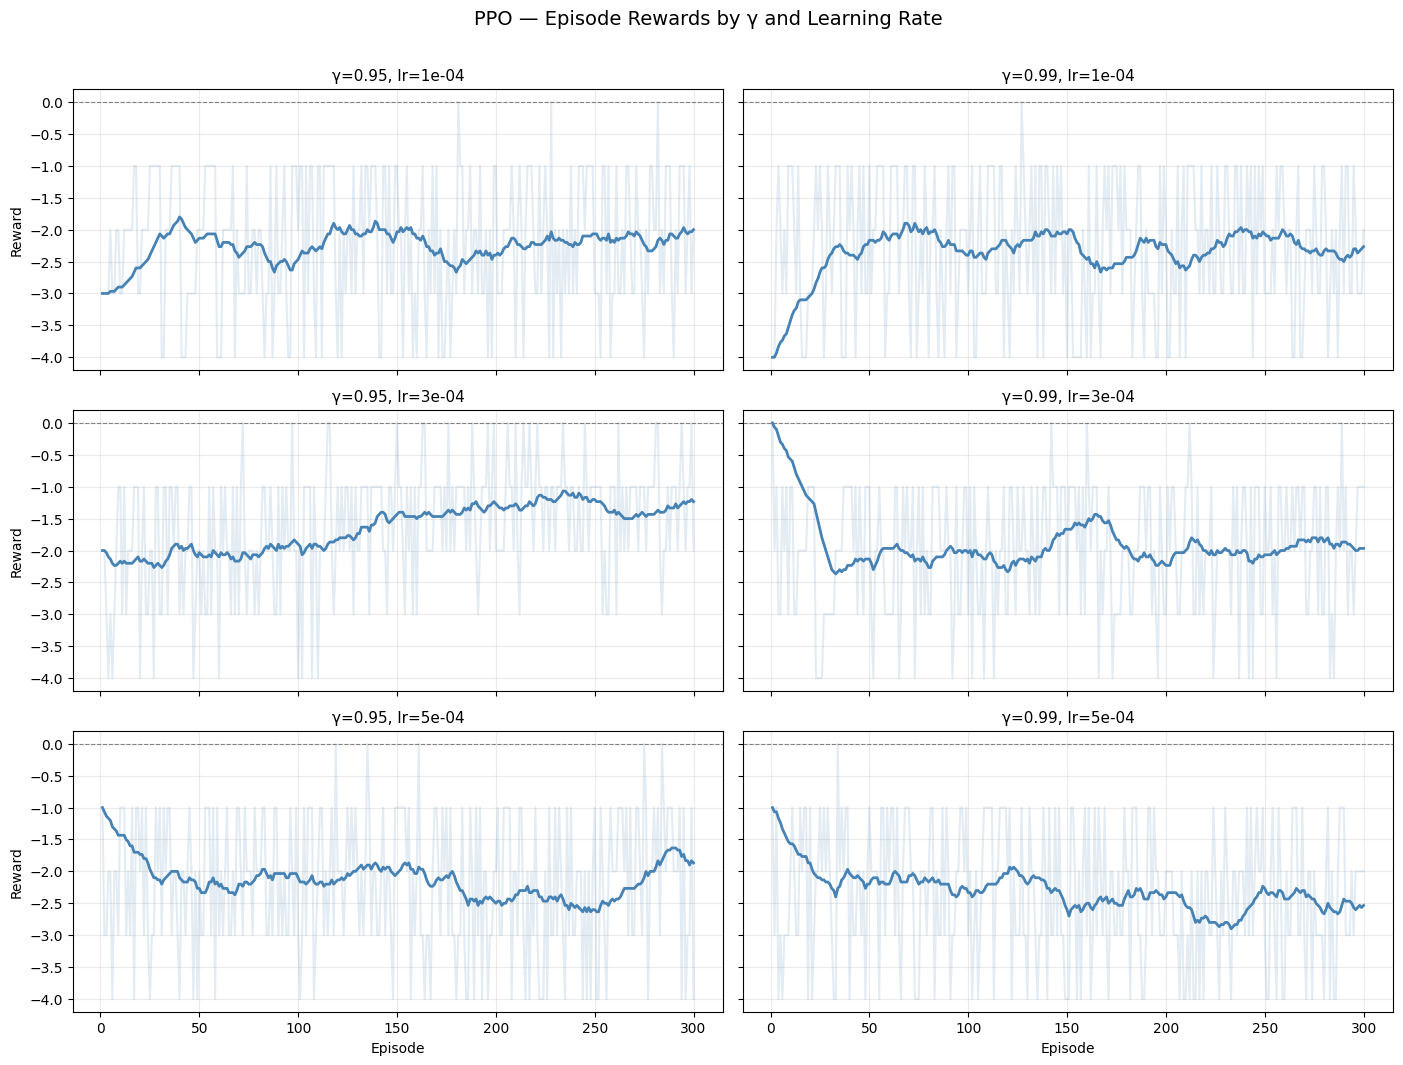

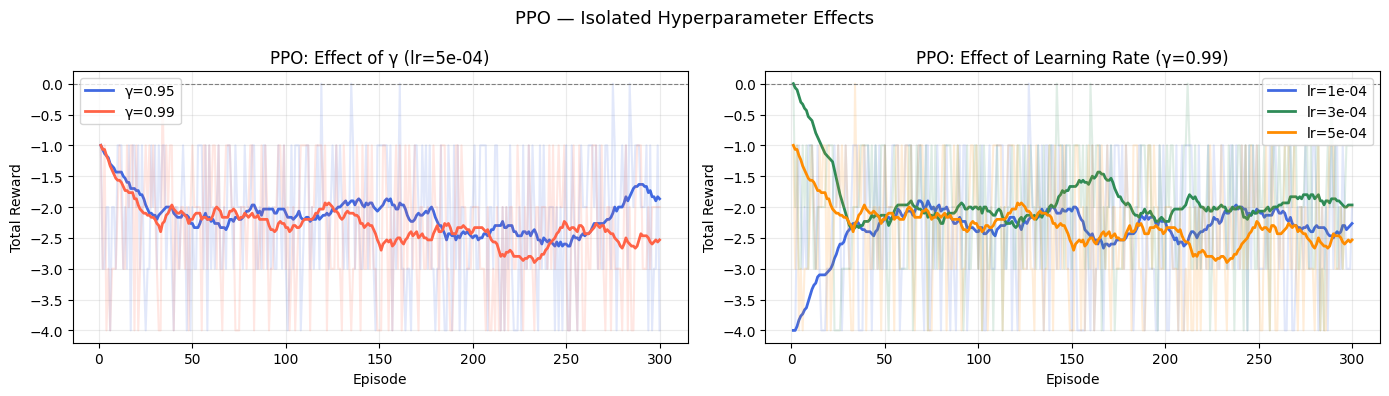

In [ ]:
# ─── All-in-one comparison ────────────────────────────────────────────────────
plot_hyperparameter_study(
    ppo_results,
    title='PPO — Hyperparameter Study',
    smooth_window=30,
)

# ─── Grid view ────────────────────────────────────────────────────────────────
plot_gamma_lr_grid(
    ppo_results,
    title='PPO — Episode Rewards by γ and Learning Rate',
    gammas=GAMMAS,
    lrs=LRS,
)

# ─── Isolated effects ─────────────────────────────────────────────────────────
# Derive best hyperparameters from PPO results (independent of DDQN)
tail = min(50, N_EPISODES // 5)
best_lr_ppo = max(LRS, key=lambda lr: np.mean([
    np.mean(ppo_results[f'\u03b3={g}, lr={lr:.0e}'][-tail:]) for g in GAMMAS]))
best_gamma_ppo = max(GAMMAS, key=lambda g: np.mean([
    np.mean(ppo_results[f'\u03b3={g}, lr={lr:.0e}'][-tail:]) for lr in LRS]))
print(f'PPO Best LR: {best_lr_ppo:.0e}  |  PPO Best \u03b3: {best_gamma_ppo}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for gamma, color in zip(GAMMAS, ['royalblue', 'tomato']):
    key  = f'\u03b3={gamma}, lr={best_lr_ppo:.0e}'
    rews = ppo_results[key]
    eps  = np.arange(1, len(rews) + 1)
    axes[0].plot(eps, rews, alpha=0.15, color=color)
    axes[0].plot(eps, moving_average(rews, 30), color=color, lw=2, label=f'γ={gamma}')
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_title(f'PPO: Effect of γ (lr={best_lr_ppo:.0e})', fontsize=12)
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Total Reward')
axes[0].legend(); axes[0].grid(True, alpha=0.25)

for lr, color in zip(LRS, lr_colors):
    key  = f'γ={best_gamma_ppo}, lr={lr:.0e}'
    rews = ppo_results[key]
    eps  = np.arange(1, len(rews) + 1)
    axes[1].plot(eps, rews, alpha=0.15, color=color)
    axes[1].plot(eps, moving_average(rews, 30), color=color, lw=2, label=f'lr={lr:.0e}')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_title(f'PPO: Effect of Learning Rate (γ={best_gamma_ppo})', fontsize=12)
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Total Reward')
axes[1].legend(); axes[1].grid(True, alpha=0.25)

plt.suptitle('PPO — Isolated Hyperparameter Effects', fontsize=13)
plt.tight_layout()
plt.show()

---
## 9. Dueling DDQN vs PPO — Head-to-Head Comparison

We compare the best configuration of each algorithm side-by-side.

Best DDQN config: γ=0.99, lr=5e-04  (final avg: -1.00)
Best PPO  config: γ=0.95, lr=2.5e-4  (final avg: -1.36)


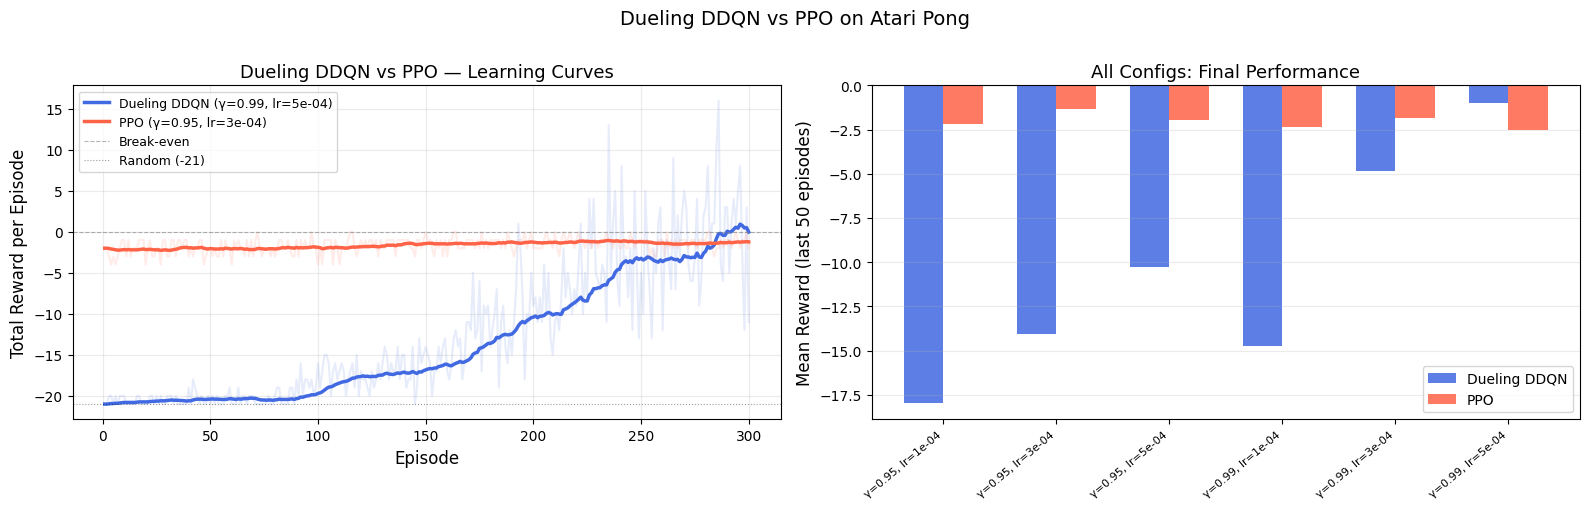

In [ ]:
# ─── Identify best configuration for each algorithm ───────────────────────────
best_ddqn_key = max(ddqn_results, key=lambda k: np.mean(ddqn_results[k][-50:]))
best_ppo_key  = max(ppo_results,  key=lambda k: np.mean(ppo_results[k][-50:]))

best_ddqn_rews = ddqn_results[best_ddqn_key]
best_ppo_rews  = ppo_results[best_ppo_key]

print(f"Best DDQN config: {best_ddqn_key}  "
      f"(final avg: {np.mean(best_ddqn_rews[-50:]):.2f})")
print(f"Best PPO  config: {best_ppo_key}  "
      f"(final avg: {np.mean(best_ppo_rews[-50:]):.2f})")

# ─── Learning curve comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: learning curves
ax = axes[0]
n_d = len(best_ddqn_rews)
n_p = len(best_ppo_rews)
ax.plot(range(1, n_d + 1), best_ddqn_rews, alpha=0.12, color='royalblue')
ax.plot(range(1, n_d + 1), moving_average(best_ddqn_rews, 30),
        color='royalblue', lw=2.5, label=f'Dueling DDQN ({best_ddqn_key})')
ax.plot(range(1, n_p + 1), best_ppo_rews, alpha=0.12, color='tomato')
ax.plot(range(1, n_p + 1), moving_average(best_ppo_rews, 30),
        color='tomato',    lw=2.5, label=f'PPO ({best_ppo_key})')
ax.axhline(0,   color='gray',  ls='--', lw=0.8, alpha=0.6, label='Break-even')
ax.axhline(-21, color='black', ls=':',  lw=0.8, alpha=0.4, label='Random (-21)')
ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Total Reward per Episode', fontsize=12)
ax.set_title('Dueling DDQN vs PPO — Learning Curves', fontsize=13)
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

# Right: full hyperparameter grid final performance comparison
ax2 = axes[1]
ddqn_finals = {k: np.mean(v[-50:]) for k, v in ddqn_results.items()}
ppo_finals  = {k: np.mean(v[-50:]) for k, v in ppo_results.items()}

labels_all  = sorted(ddqn_finals.keys())
x           = np.arange(len(labels_all))
width       = 0.35

b1 = ax2.bar(x - width/2, [ddqn_finals[k] for k in labels_all],
              width, label='Dueling DDQN', color='royalblue', alpha=0.85)
b2 = ax2.bar(x + width/2, [ppo_finals[k]  for k in labels_all],
              width, label='PPO',          color='tomato',    alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(labels_all, rotation=40, ha='right', fontsize=8)
ax2.set_ylabel('Mean Reward (last 50 episodes)', fontsize=12)
ax2.set_title('All Configs: Final Performance', fontsize=13)
ax2.axhline(0, color='gray', ls='--', lw=0.8, alpha=0.6)
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.25, axis='y')

plt.suptitle('Dueling DDQN vs PPO on Atari Pong', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

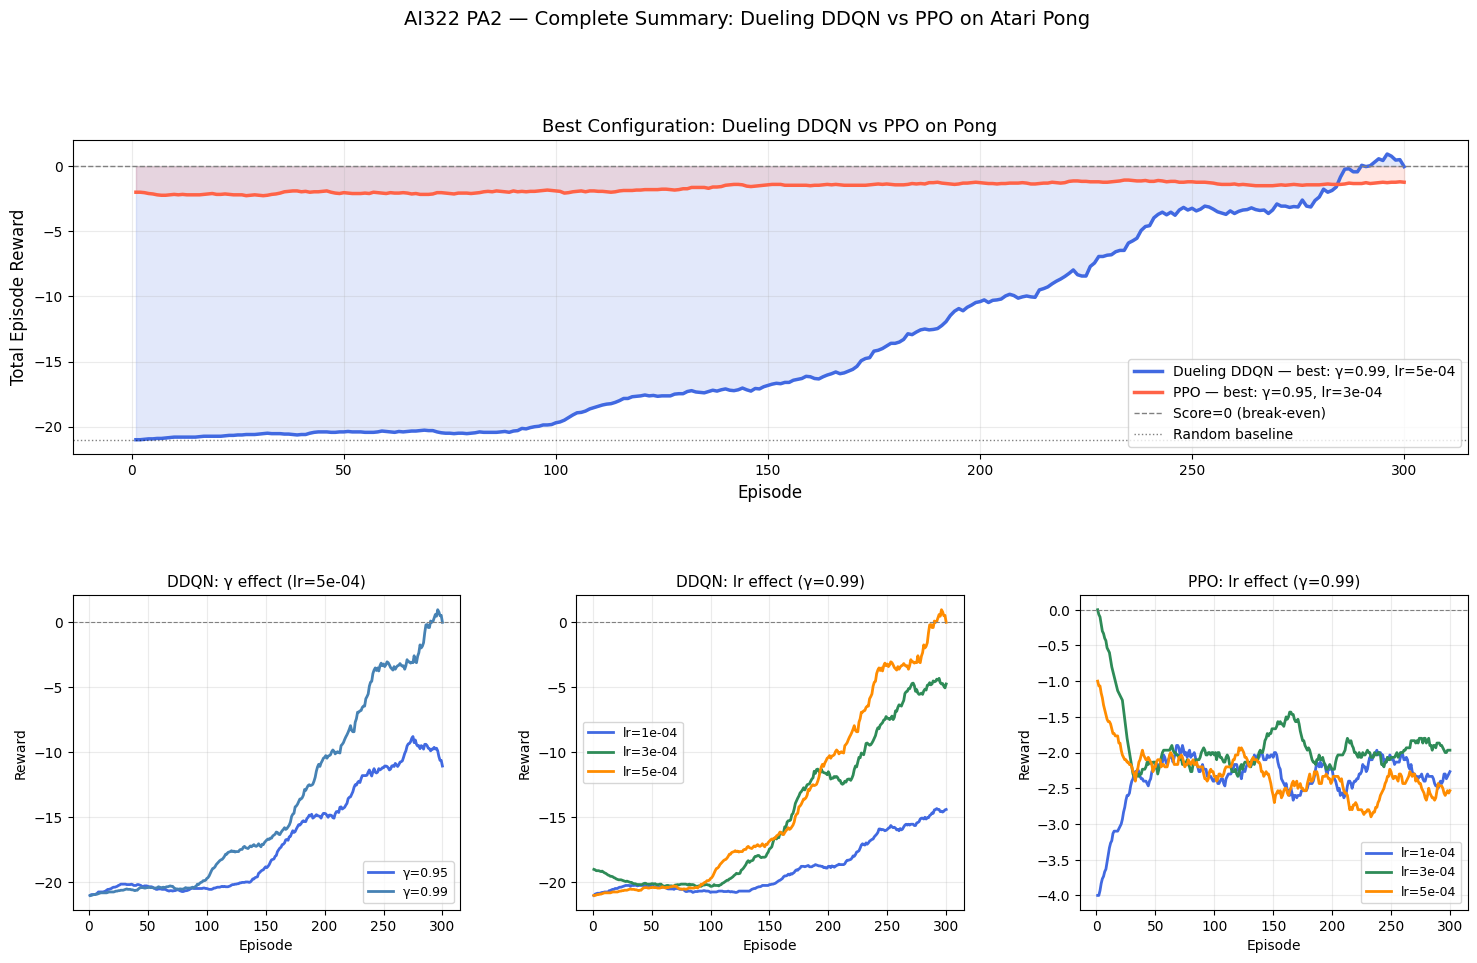

In [ ]:
# ─── Comprehensive 6-panel summary ───────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.3)

# Panel 1 & 2: DDQN vs PPO best curves
ax_main = fig.add_subplot(gs[0, :])
n_d = len(best_ddqn_rews); n_p = len(best_ppo_rews)
ax_main.fill_between(range(1, n_d+1), moving_average(best_ddqn_rews, 30),
                     alpha=0.15, color='royalblue')
ax_main.plot(range(1, n_d+1), moving_average(best_ddqn_rews, 30),
             color='royalblue', lw=2.5, label=f'Dueling DDQN — best: {best_ddqn_key}')
ax_main.fill_between(range(1, n_p+1), moving_average(best_ppo_rews, 30),
                     alpha=0.15, color='tomato')
ax_main.plot(range(1, n_p+1), moving_average(best_ppo_rews, 30),
             color='tomato', lw=2.5, label=f'PPO — best: {best_ppo_key}')
ax_main.axhline(0,   color='gray',  ls='--', lw=1, label='Score=0 (break-even)')
ax_main.axhline(-21, color='black', ls=':',  lw=1, alpha=0.5, label='Random baseline')
ax_main.set_xlabel('Episode', fontsize=12)
ax_main.set_ylabel('Total Episode Reward', fontsize=12)
ax_main.set_title('Best Configuration: Dueling DDQN vs PPO on Pong', fontsize=13)
ax_main.legend(fontsize=10, loc='lower right')
ax_main.grid(True, alpha=0.25)

# Panels 3-5: DDQN gamma/lr effects
ax_dg = fig.add_subplot(gs[1, 0])
for gamma, c in zip(GAMMAS, ['royalblue', 'steelblue']):
    key = f'γ={gamma}, lr={best_lr:.0e}'
    r   = ddqn_results[key]
    ax_dg.plot(range(1, len(r)+1), moving_average(r, 30), lw=2, color=c, label=f'γ={gamma}')
ax_dg.axhline(0, color='gray', ls='--', lw=0.8)
ax_dg.set_title(f'DDQN: γ effect (lr={best_lr:.0e})', fontsize=11)
ax_dg.set_xlabel('Episode'); ax_dg.set_ylabel('Reward')
ax_dg.legend(fontsize=9); ax_dg.grid(True, alpha=0.25)

ax_dl = fig.add_subplot(gs[1, 1])
for lr, c in zip(LRS, lr_colors):
    key = f'γ={best_gamma}, lr={lr:.0e}'
    r   = ddqn_results[key]
    ax_dl.plot(range(1, len(r)+1), moving_average(r, 30), lw=2, color=c, label=f'lr={lr:.0e}')
ax_dl.axhline(0, color='gray', ls='--', lw=0.8)
ax_dl.set_title(f'DDQN: lr effect (γ={best_gamma})', fontsize=11)
ax_dl.set_xlabel('Episode'); ax_dl.set_ylabel('Reward')
ax_dl.legend(fontsize=9); ax_dl.grid(True, alpha=0.25)

# Panel 6: PPO lr effect
ax_pl = fig.add_subplot(gs[1, 2])
for lr, c in zip(LRS, lr_colors):
    key = f'γ={best_gamma_ppo}, lr={lr:.0e}'
    r   = ppo_results[key]
    ax_pl.plot(range(1, len(r)+1), moving_average(r, 30), lw=2, color=c, label=f'lr={lr:.0e}')
ax_pl.axhline(0, color='gray', ls='--', lw=0.8)
ax_pl.set_title(f'PPO: lr effect (γ={best_gamma_ppo})', fontsize=11)
ax_pl.set_xlabel('Episode'); ax_pl.set_ylabel('Reward')
ax_pl.legend(fontsize=9); ax_pl.grid(True, alpha=0.25)

fig.suptitle('AI322 PA2 — Complete Summary: Dueling DDQN vs PPO on Atari Pong',
             fontsize=14, y=1.01)
plt.show()

In [ ]:
# ─── Quantitative comparison table ────────────────────────────────────────────
print("=" * 70)
print(f"{'Configuration':<32} {'DDQN Final':>12} {'PPO Final':>12} {'Winner':>10}")
print("-" * 70)

for label in sorted(ddqn_results.keys()):
    d = np.mean(ddqn_results[label][-50:])
    p = np.mean(ppo_results[label][-50:])
    winner = 'DDQN' if d > p else 'PPO '
    print(f"  {label:<30} {d:>12.2f} {p:>12.2f} {winner:>10}")

print("-" * 70)
ddqn_mean_all = np.mean([np.mean(v[-50:]) for v in ddqn_results.values()])
ppo_mean_all  = np.mean([np.mean(v[-50:]) for v in ppo_results.values()])
print(f"  {'Average across all configs':<30} {ddqn_mean_all:>12.2f} {ppo_mean_all:>12.2f}")
print("=" * 70)

print(f"\nBest DDQN: {best_ddqn_key}  →  {np.mean(best_ddqn_rews[-50:]):.2f}")
print(f"Best PPO : {best_ppo_key}   →  {np.mean(best_ppo_rews[-50:]):.2f}")

Configuration                      DDQN Final    PPO Final     Winner
----------------------------------------------------------------------
  γ=0.95, lr=1e-04                     -17.98        -2.16       PPO 
  γ=0.95, lr=2.5e-4                     -14.06        -1.36       PPO 
  γ=0.95, lr=5e-04                     -10.28        -1.98       PPO 
  γ=0.99, lr=1e-04                     -14.74        -2.36       PPO 
  γ=0.99, lr=2.5e-4                      -4.82        -1.86       PPO 
  γ=0.99, lr=5e-04                      -1.00        -2.52       DDQN
----------------------------------------------------------------------
  Average across all configs           -10.48        -2.04

Best DDQN: γ=0.99, lr=5e-04  →  -1.00
Best PPO : γ=0.95, lr=2.5e-4   →  -1.36


---
## 10. Results Summary and Discussion


### 10.1 Hyperparameter Results

#### Dueling DDQN - Mean reward over last 50 episodes

| gamma | lr | Final Avg |
|---|---|---:|
| 0.95 | 1e-4 | -17.98 |
| 0.95 | 2.5e-4 | -14.06 |
| 0.95 | 5e-4 | -10.28 |
| 0.99 | 1e-4 | -14.74 |
| 0.99 | 2.5e-4 | -4.82 |
| **0.99** | **5e-4** | **-1.00** |

#### PPO - Mean reward over last 50 episodes

| gamma | lr | Final Avg |
|---|---|---:|
| 0.95 | 1e-4 | -2.16 |
| **0.95** | **2.5e-4** | **-1.36** |
| 0.95 | 5e-4 | -1.98 |
| 0.99 | 1e-4 | -2.36 |
| 0.99 | 2.5e-4 | -1.86 |
| 0.99 | 5e-4 | -2.52 |

### 10.2 Head-to-Head Summary

| Metric | DDQN | PPO |
|---|---:|---:|
| Best config | gamma = 0.99, lr = 5e-4 | gamma = 0.95, lr = 2.5e-4 |
| Best final score | **-1.00** | -1.36 |
| Average across all 6 configs | -10.48 | **-2.04** |
| Number of grid points won | 1/6 | **5/6** |

**Interpretation:** PPO was the more reliable algorithm across the hyperparameter grid, while DDQN achieved the best single tuned run.

### 10.3 What Changed with gamma and Learning Rate

1. **PPO was much more robust.** PPO stayed in a narrow band from `-1.36` to `-2.52`, while DDQN ranged from `-1.00` to `-17.98`.
2. **The gamma effect was algorithm-specific.** DDQN clearly benefited from `gamma = 0.99`, but PPO performed better with `gamma = 0.95` at every tested learning rate in this 300-episode budget.
3. **Learning-rate trends differed by algorithm.** DDQN improved as lr increased across the tested range, while PPO was best at the middle value `2.5e-4`.
4. **Neither algorithm solved Pong in 300 episodes.** Both best runs remained negative, but both improved substantially relative to the random-play baseline near `-21`.

These results indicate that `gamma = 0.99` was beneficial for DDQN, whereas PPO consistently favored `gamma = 0.95` within the present 300-episode training budget.

### 10.4 Comparison with Published Atari Results

Direct comparison with high-performing Atari Pong scores in the literature must be made cautiously because the evaluation protocol and training budget are materially different. Machado et al. (2018) report ALE benchmark results at `10M`, `50M`, `100M`, and `200M` frames, and note that `200M` frames correspond to approximately `38` days of real-time gameplay. Their DQN benchmark is averaged over five independent trials and evaluated over the last `100` training episodes, with episodes capped at `18,000` frames and stochasticity introduced through sticky actions (`ζ = 0.25`). Under that protocol, DQN on Pong is still negative at `10M` frames (`-15.9 ± 1.0`) and becomes strongly positive only at much larger budgets, reaching `12.2 ± 1.0` at `50M` frames and about `15` by `100M-200M` frames.

By contrast, the present study used only `300` episodes per configuration, corresponding to a rough order-of-magnitude budget of about `1.2M` ALE frames. The gap between our final scores and the large-budget ALE benchmark scores should therefore be interpreted primarily as a consequence of training budget and protocol, rather than as evidence that the agents failed to learn. Within this constrained setting, the results remain meaningful: both methods improved substantially from the random-play baseline near `-21`, and both approached break-even play, with DDQN reaching `-1.00` and PPO reaching `-1.36` in their best settings. The fairest interpretation is therefore that this notebook captures early-stage learning under a limited compute budget, not asymptotic Atari performance.

### 10.5 Conclusion

The results support a differentiated conclusion. PPO was the stronger algorithm under the present limited-budget regime: it won `5` of the `6` tested hyperparameter settings and achieved the superior average final reward across the grid (`-2.04` versus `-10.48`), indicating greater robustness and lower sensitivity to hyperparameter choice. DDQN, however, attained the best single tuned configuration at `gamma = 0.99` and `lr = 5e-4`, reaching `-1.00`, which was slightly better than PPO's best score of `-1.36` at `gamma = 0.95` and `lr = 2.5e-4`.

Accordingly, the principal finding of this study is not that one method universally dominates the other on Pong. Rather, under a short training horizon, PPO provides the more reliable optimization behavior, whereas DDQN offers a higher upside when well tuned but exhibits substantially greater sensitivity to the choice of discount factor and learning rate. This interpretation is consistent with the ALE literature, which shows that strong positive Pong performance typically emerges only after training budgets far larger than those used in the present experiment.


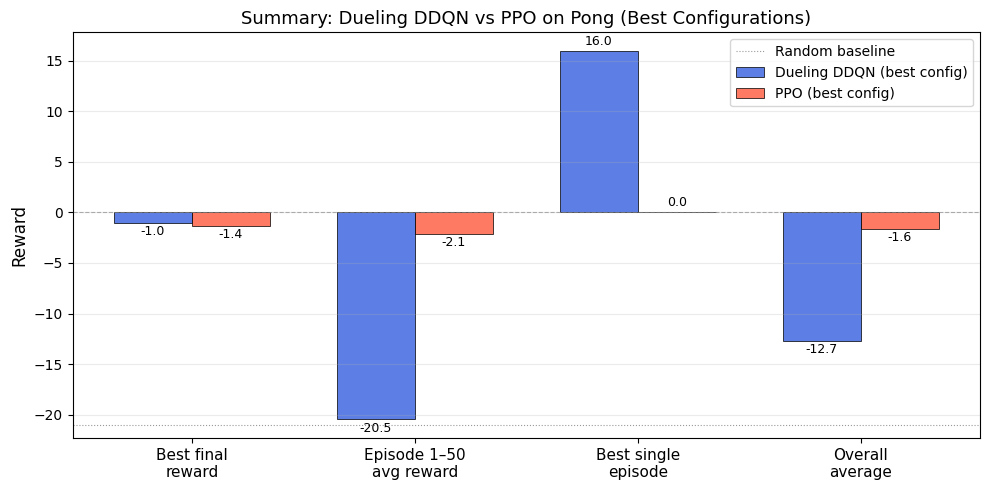


EXPERIMENT COMPLETE
  DDQN best config : γ=0.99, lr=5e-04
  PPO  best config : γ=0.95, lr=2.5e-4
  DDQN final score : -1.00
  PPO  final score : -1.36


In [ ]:
# ─── Final algorithm comparison bar chart ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

metrics = {
    'Best final\nreward': (
        np.mean(best_ddqn_rews[-50:]),
        np.mean(best_ppo_rews[-50:])
    ),
    'Episode 1–50\navg reward': (
        np.mean(best_ddqn_rews[:50]),
        np.mean(best_ppo_rews[:50])
    ),
    'Best single\nepisode': (
        max(best_ddqn_rews),
        max(best_ppo_rews)
    ),
    'Overall\naverage': (
        np.mean(best_ddqn_rews),
        np.mean(best_ppo_rews)
    ),
}

x    = np.arange(len(metrics))
w    = 0.35
ddqn_vals = [v[0] for v in metrics.values()]
ppo_vals  = [v[1] for v in metrics.values()]

b1 = ax.bar(x - w/2, ddqn_vals, w, label='Dueling DDQN (best config)',
            color='royalblue', alpha=0.85, edgecolor='black', lw=0.6)
b2 = ax.bar(x + w/2, ppo_vals,  w, label='PPO (best config)',
            color='tomato',    alpha=0.85, edgecolor='black', lw=0.6)

for bar, val in zip(list(b1) + list(b2), ddqn_vals + ppo_vals):
    ypos = bar.get_height() + (0.3 if val >= 0 else -1.5)
    ax.text(bar.get_x() + bar.get_width()/2, ypos,
            f"{val:.1f}", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics.keys(), fontsize=11)
ax.set_ylabel('Reward', fontsize=12)
ax.set_title('Summary: Dueling DDQN vs PPO on Pong (Best Configurations)',
             fontsize=13)
ax.axhline(0,   color='gray',  ls='--', lw=0.8, alpha=0.6)
ax.axhline(-21, color='black', ls=':',  lw=0.8, alpha=0.4, label='Random baseline')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("EXPERIMENT COMPLETE")
print("="*60)
print(f"  DDQN best config : {best_ddqn_key}")
print(f"  PPO  best config : {best_ppo_key}")
print(f"  DDQN final score : {np.mean(best_ddqn_rews[-50:]):.2f}")
print(f"  PPO  final score : {np.mean(best_ppo_rews[-50:]):.2f}")
print("="*60)

---
## References

1. **Machado et al. (2018)** — Revisiting the Arcade Learning Environment: Evaluation Protocols and Open Problems for General Agents. *JAIR*, 61, 523–562. Course PDF provided as *View of Revisiting the Arcade Learning Environment_ Evaluation Protocols and Open Problems for General Agents.pdf*.
2. **Mnih et al. (2015)** — Human-level control through deep reinforcement learning. *Nature*, 518, 529–533.
3. **van Hasselt et al. (2016)** — Deep Reinforcement Learning with Double Q-learning. *AAAI*.
4. **Wang et al. (2016)** — Dueling Network Architectures for Deep Reinforcement Learning. *ICML*.
5. **Schulman et al. (2015)** — High-Dimensional Continuous Control Using Generalized Advantage Estimation. *ICLR*.
6. **Schulman et al. (2017)** — Proximal Policy Optimization Algorithms. *arXiv:1707.06347*.
7. **Bellemare et al. (2013)** — The Arcade Learning Environment: An Evaluation Platform for General Agents. *JAIR*, 47, 253–279.
8. Gymnasium documentation: https://gymnasium.farama.org
